In [63]:
import ast
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [19]:
transcript_info = pd.read_csv(
    "BECancerResistome/data/TranscriptInfoBiomartExport17122024.txt.gz", sep="\t"
)
transcript_length = transcript_info.groupby("Transcript stable ID version")[
    "Transcript length (including UTRs and CDS)"
].first()

/var/folders/5v/3w39hhps0k15qx5v_t82tpvh0000gn/T/ipykernel_21233/585090872.py:1: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  transcript_info = pd.read_csv(


In [20]:
transcript_info.sample(5)

,Gene stable ID,Gene stable ID version,Transcript stable ID,Transcript stable ID version,Transcript length (including UTRs and CDS),Chromosome/scaffold name,Gene start (bp),Gene end (bp),Strand,Transcript start (bp),Transcript end (bp),Transcript type,Gene type,Gene % GC content,Transcript count
50968,ENSG00000172524,ENSG00000172524.12,ENST00000547289,ENST00000547289.2,2006,HSCHR6_MHC_QBL_CTG1,1391236,1403864,1,1391859,1403864,protein_coding,protein_coding,42.67,4
55310,ENSG00000130204,ENSG00000130204.13,ENST00000592434,ENST00000592434.5,3415,19,44890569,44903689,1,44891231,44903686,protein_coding,protein_coding,56.25,7
96894,ENSG00000198821,ENSG00000198821.12,ENST00000362089,ENST00000362089.10,1600,1,167425027,167518640,-1,167430640,167518529,protein_coding,protein_coding,47.03,40
83007,ENSG00000147689,ENSG00000147689.17,ENST00000276699,ENST00000276699.10,1858,8,123178960,123210079,1,123182681,123210074,protein_coding,protein_coding,49.80,9
91162,ENSG00000043093,ENSG00000043093.15,ENST00000460412,ENST00000460412.6,2326,3,182938074,182985953,-1,182943776,182985932,protein_coding,protein_coding,39.56,8


## Import Coelho et at. dataset


In [4]:
be_coelho = pd.read_excel(
    "data/41588_2024_1948_MOESM4_ESM.xlsx", sheet_name="ST2 BE z-scores"
)

In [5]:
be_coelho = be_coelho.set_index(["guide", "editor"])[
    [c for c in be_coelho if "average_zscore" in c]
]
be_coelho.sample(15)

,,L2FC_HT29_DebCet_plasmid_average_zscore,L2FC_HT29_Tram_plasmid_average_zscore,L2FC_HT29_Pict_plasmid_average_zscore,L2FC_HT29_Control_plasmid_average_zscore,L2FC_H23_Adag_plasmid_average_zscore,L2FC_H23_Sotor_plasmid_average_zscore,L2FC_H23_Control_plasmid_average_zscore,L2FC_PC9_Control_plasmid_average_zscore,L2FC_PC9_Osim_plasmid_average_zscore,L2FC_PC9_Gefit_plasmid_average_zscore,L2FC_MHHES1_Olap_plasmid_average_zscore,L2FC_MHHES1_Nirap_plasmid_average_zscore,L2FC_MHHES1_Control_plasmid_average_zscore
guide,editor,,,,,,,,,,,,,
CAGCCGTATTTCTACTGCGA,CBE,-1.551326,-0.945318,-1.208338,-0.841034,-1.117139,-0.163077,-0.919747,-0.847267,-0.130302,-0.229618,NaN,NaN,NaN
GCTTGCATTGATAGAAATGG,ABE,-0.066286,0.033245,-0.043968,-0.456703,-0.017308,0.237763,-0.210030,-0.675271,-0.566343,-0.157346,-0.594972,-0.930142,-0.663862
CCTAAGCCCCTGGTGACAGA,CBE,1.003993,0.723163,0.722046,0.957063,0.531872,1.028056,1.107534,1.198214,0.912815,0.565889,NaN,NaN,NaN
TCGGATAGCCCCGCCTGAAG,CBE,0.674465,0.487291,0.856352,0.910718,0.872875,0.944919,1.408129,0.463637,0.189481,0.059953,NaN,NaN,NaN
GCTACTCATCTTCAACAAGC,ABE,1.034110,0.584694,0.691951,0.698707,2.700465,-0.036576,-0.336702,0.543766,0.623211,0.623466,1.812175,1.795183,0.916931
CCATCACACCACCTGACCAA,CBE,0.924586,0.557300,0.779542,-0.068492,-0.273827,-0.795097,0.148760,0.581742,0.582224,0.427417,NaN,NaN,NaN
TCGACTCGATAGAGCTTATC,CBE,-1.801371,-1.347080,-1.033448,-1.952116,-2.195032,-1.505419,-2.167148,-2.506400,-1.458815,-2.000858,NaN,NaN,NaN
AAGCTCAAAACTGACATTAA,ABE,0.924909,0.272350,0.418461,0.415734,0.501485,-0.629155,0.493057,0.447354,0.327771,0.333736,-0.001367,-0.166633,-0.222004
GCGGGGGGCGGAGGCTGCTG,ABE,0.361617,-0.370247,-1.109668,-1.046031,0.054264,-0.644503,-0.645174,-0.819549,-0.399885,-0.008366,-2.463886,-2.201650,-1.067659


## Import sgRNA Beagle Library


In [67]:
variants_beagle = pd.read_csv(f"data/BeagleCoelho/EG_collab-guides-HGVS.txt", sep="\t")
variants_beagle["hgvs"] = variants_beagle["hgvs"].apply(
    lambda x: np.nan if x == "-" else ast.literal_eval(x)
)
variants_beagle.sample(10)

,Input,CRISPR Enzyme,Edit Type,Edit Window,Target Taxon,Target Assembly,Target Genome Sequence,Target Gene ID,Target Gene Symbol,Target Gene Strand,...,sgRNA Orientation,Nucleotide Edits (global),Guide Edits,Nucleotide Edits,Amino Acid Edits,Mutation Category,Constraint Violations,Note,editor,hgvs
12166,ENST00000333681.5,SpyoCas9NG,A-G,4..8,9606,GRCh38,NC_000018.10,ENSG00000171791,BCL2,-,...,antisense,63318357A>G;63318356A>G,A_6;A_5,310T>C;311T>C,Phe104Pro,Missense,NaN,NaN,ABE,[ENST00000333681.5:c.310T>C;311T>C]
21172,ENST00000646891.2,SpyoCas9NG,A-G,4..8,9606,GRCh38,NC_000007.14,ENSG00000157764,BRAF,-,...,antisense,140783119A>G;140783118A>G,A_8;A_7,1216T>C;1217T>C,Leu406Pro,Missense,NaN,NaN,ABE,[ENST00000646891.2:c.1216T>C;1217T>C]
700,ENST00000262948.10,SpyoCas9NG,A-G,4..8,9606,GRCh38,NC_000019.10,ENSG00000126934,MAP2K2,-,...,antisense,4099327A>G,A_7,793T>C,Tyr265His,Missense,NaN,NaN,ABE,[ENST00000262948.10:c.793T>C]
10817,ENST00000307102.10,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000015.10,ENSG00000169032,MAP2K1,+,...,antisense,"66489211G>A, 66489214G>A","C_8, C_5","961-4G>A, 961-1G>A","(NC), (NC)","Intron, Splice-acceptor",NaN,NaN,CBE,"[ENST00000307102.10:c.961-4G>A, ENST0000030710..."
2847,ENST00000263967.4,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000003.12,ENSG00000121879,PIK3CA,+,...,sense,179204539C>T;179204540C>T;179204541C>T,C_5;C_6;C_7,1096C>T;1097C>T;1098C>T,Pro366Phe,Missense,NaN,NaN,CBE,[ENST00000263967.4:c.1096C>T;1097C>T;1098C>T]
11226,ENST00000311936.8,SpyoCas9NG,A-G,4..8,9606,GRCh38,NC_000012.12,ENSG00000133703,KRAS,-,...,sense,25225669T>C,A_5,395A>G,Asp132Gly,Missense,NaN,NaN,ABE,[ENST00000311936.8:c.395A>G]
14072,ENST00000366794.10,SpyoCas9NG,A-G,4..8,9606,GRCh38,NC_000001.11,ENSG00000143799,PARP1,-,...,sense,"226377193T>C;226377192T>C, 226377190T>C","A_5;A_6, A_8","1856A>G;1857A>G, 1859A>G","Glu619Gly, Glu620Gly","Missense, Missense",NaN,NaN,ABE,"[ENST00000366794.10:c.1856A>G;1857A>G, ENST000..."
22923,ENST00000649815.2,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000014.9,ENSG00000142208,AKT1,-,...,sense,"104772463G>A, 104772462G>A","C_6, C_7","1173-11C>T, 1173-10C>T","(NC), (NC)","Intron, Intron",NaN,NaN,CBE,"[ENST00000649815.2:c.1173-11C>T, ENST000006498..."
13837,ENST00000366794.10,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000001.11,ENSG00000143799,PARP1,-,...,antisense,"226370506C>T, 226370503C>T","C_8, C_5","2082G>A, 2085G>A","Gln694Gln, Lys695Lys","Silent, Silent",NaN,NaN,CBE,"[ENST00000366794.10:c.2082G>A, ENST00000366794..."
11434,ENST00000311936.8,SpyoCas9NG,A-G,4..8,9606,GRCh38,NC_000012.12,ENSG00000133703,KRAS,-,...,sense,"25227363T>C, 25227361T>C","A_5, A_7","161A>G, 163A>G","Asp54Gly, Ile55Val","Missense, Missense",NaN,NaN,ABE,"[ENST00000311936.8:c.161A>G, ENST00000311936.8..."


## Import Variants VEP


In [22]:
variants_vep = pd.read_csv(
    f"data/BeagleCoelho/EG_collab-guides-VEP-HGVS-output.txt", sep="\t"
)
variants_vep.shape

/var/folders/5v/3w39hhps0k15qx5v_t82tpvh0000gn/T/ipykernel_21233/3279890295.py:1: DtypeWarning: Columns (23,84,85,86,87,88,89,90,91,107) have mixed types. Specify dtype option on import or set low_memory=False.
  variants_vep = pd.read_csv(


(68764, 117)

In [23]:
variants_vep = variants_vep.query("MANE == 'MANE_Select'")
variants_vep.shape

(26484, 117)

In [24]:
variants_vep["editor"] = (
    variants_vep["UPLOADED_ALLELE"]
    .apply(lambda v: "ABE" if v in {"G/A", "A/G"} else "CBE")
    .values
)

#### Number of guides per gene


In [25]:
plot_df = (
    variants_vep.groupby(["Feature", "SYMBOL"])["#Uploaded_variation"]
    .count()
    .sort_values(ascending=False)
).reset_index()
plot_df["Transcript length"] = plot_df["Feature"].map(transcript_length)

Text(0, 0.5, 'Gene')

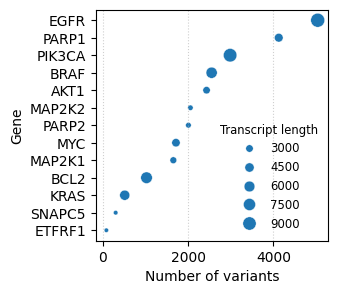

In [26]:
_, ax = plt.subplots(figsize=(3, 3))

sns.scatterplot(
    data=plot_df,
    x="#Uploaded_variation",
    y="SYMBOL",
    size="Transcript length",
    sizes=(10, 100),
    ax=ax,
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles=handles[1:],
    labels=labels[1:],
    title="Transcript length",
    title_fontsize="small",
    fontsize="small",
    frameon=False,
)

ax.grid(axis="x", linestyle=":", alpha=0.6)

ax.set_xlabel("Number of variants")
ax.set_ylabel("Gene")

## Merging DataFrames


### Input DataFrames

- **`variants_beagle`**: Contains sgRNA sequences, editors, and associated transcripts with keys (`sgRNA`, `editor`, `transcript`).
- **`variants_vep`**: Includes variant information with the key `#Uploaded_variation`.
- **`be_coelho`**: Represents sgRNA-editor pairs with keys (`sgRNA`, `editor`).

### Merging Steps

1. **Merge `be_coelho` with `variants_beagle`**:
   ```python
   be_merged = pd.merge(
       be_coelho.reset_index(),
       variants_beagle,
       left_on=["guide", "editor"],
       right_on=["sgRNA Sequence", "editor"],
       how="inner",
   )
   ```
2. **Merge `be_merged` with `variants_vep` after exploding `hgvs`**:
   ```python
    be_merged_vep = pd.merge(
        be_merged.dropna(subset=["hgvs"]).explode("hgvs"),
        variants_vep,
        left_on="hgvs",
        right_on="#Uploaded_variation",
        how="inner",
    )
   ```


In [71]:
be_merged = pd.merge(
    be_coelho.reset_index(),
    variants_beagle,
    left_on=["guide", "editor"],
    right_on=["sgRNA Sequence", "editor"],
    how="inner",
)

In [72]:
be_merged_vep = pd.merge(
    be_merged.dropna(subset=["hgvs"]).explode("hgvs"),
    variants_vep,
    left_on="hgvs",
    right_on="#Uploaded_variation",
    how="inner",
)

In [73]:
be_merged_vep.sample(10)

,guide,editor_x,L2FC_HT29_DebCet_plasmid_average_zscore,L2FC_HT29_Tram_plasmid_average_zscore,L2FC_HT29_Pict_plasmid_average_zscore,L2FC_HT29_Control_plasmid_average_zscore,L2FC_H23_Adag_plasmid_average_zscore,L2FC_H23_Sotor_plasmid_average_zscore,L2FC_H23_Control_plasmid_average_zscore,L2FC_PC9_Control_plasmid_average_zscore,...,NMD,AA,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,mutfunc_exp,mutfunc_int,mutfunc_mod,mutfunc_motif,editor_y
36501,CGGCTGCACCGAGTCGTAGT,CBE,0.108207,0.281315,0.130442,-0.165851,0.537873,0.595271,0.332814,0.713608,...,-,G,-,-,-,-,-,-,-,ABE
35547,CTCCTCTGCTTGGACGGACA,CBE,1.162023,0.610285,0.756205,0.779954,0.596317,0.570249,0.367716,1.180433,...,-,G,-,-,-,-,-,-,-,ABE
2766,TCCCAGAGGAAAAGCAACGG,ABE,-0.626270,-0.729838,-0.718251,-1.113886,-0.373280,0.049157,0.814647,-1.177739,...,-,T,-,-,-,-,-,-,-,CBE
6793,GGACATAACCAGCCACCTCC,ABE,-2.216390,-3.154525,-2.144457,-1.995823,-1.416720,-0.965481,-1.673199,-3.823385,...,-,T,-,-,-,0,-,-,-,CBE
40391,TCGGTCCAAGATCTGCAGCC,CBE,0.155692,0.555110,1.152268,0.429036,1.036160,1.127819,1.066122,0.583352,...,-,G,-,-,-,-0.00398,-,-,-,ABE
10940,TCAGAGCTGGGCGCGGGCAA,ABE,-0.845169,-0.100060,-0.556365,-0.328744,-0.723241,-0.074423,-0.207354,-0.318925,...,-,A,-,-,-,-,1.0588,1.1448,-,ABE
38217,TTTTCCTCTGGGACAGGACT,CBE,0.891085,-0.140142,0.292829,0.009513,-0.309394,-0.148876,-0.061811,0.482459,...,-,C,7.997,-0.041,7.956,-,-,-,-,CBE
12482,AGAGGGTAGGGGAAGACCAC,ABE,-0.922409,-0.646189,-0.197658,-0.417242,-0.605943,-0.885567,-0.113862,-0.120873,...,-,T,-,-,-,-,-,-,-,CBE
34732,GTACCGCTGACGGGGCGCCC,CBE,-0.239728,-0.408433,0.002738,-0.192295,-0.600000,0.170041,-0.935268,0.098983,...,-,G,2.112,6.420,8.532,-,-,-0.19860,-,ABE
15692,CTGGACCTCACTGAGGATGG,ABE,-3.150052,-3.013372,-3.343937,-3.262162,-1.068620,-1.104384,-1.407880,-3.042663,...,-,T,-,-,-,2.10038,-,-,-,CBE


Export combined dataset


In [74]:
be_merged_vep.to_csv("data/BeagleCoelho/BE_merged_vep.tsv", index=False, sep="\t")